In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('/content/drive/MyDrive/Sentiment_Analysis/imdb_cleaned.csv')

# Display the first five rows
df.head()

,Review,sentiment
0,film fun person like good campy feature film e...,pos
1,fondness chris rock varies movie hated lethal ...,pos
2,high school friend andre kriegman cal gabriel ...,pos
3,story little girl growing up colonial africa b...,pos
4,must see film understand reality read book m d...,pos


In [3]:
# Input feature
X = df['Review']

# Target
y = df['sentiment']

print("Number of reviews:", len(X))
print("Number of labels:", len(y))

Number of reviews: 49582
Number of labels: 49582


In [4]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=6,
    stratify=y # Maintains the class distribution
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Create the Bag of Words vectorizer
# ngram_range=(1,1) means we use only individual words (unigrams)
bow_vectorizer = CountVectorizer(
    ngram_range=(1, 1)
)

# Learn the vocabulary from the training data
# and convert the training reviews into numerical features
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Convert the test reviews using the vocabulary learned from the training data
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW training shape:", X_train_bow.shape)
print("BoW testing shape:", X_test_bow.shape)

BoW training shape: (39665, 81649)
BoW testing shape: (9917, 81649)


In [6]:
print("Number of BoW features:",
      len(bow_vectorizer.vocabulary_))

Number of BoW features: 81649


In [7]:
# First 30 vocabulary terms alphabetically
vocabulary = bow_vectorizer.get_feature_names_out()

print(vocabulary[:30])

['aa' 'aaa' 'aaaaaaaaaaaahhhhhhhhhhhhhh' 'aaaaaaaargh' 'aaaaaaah' 'aaaaah'
 'aaaaahhhh' 'aaaaargh' 'aaaaarrrrrrgggggghhhhhh' 'aaaaatch' 'aaaahhhhhh'
 'aaaahhhhhhh' 'aaaand' 'aaaarrgh' 'aaaggghhhhhhh' 'aaagh' 'aaah'
 'aaahhhhhhh' 'aaall' 'aaam' 'aaand' 'aaargh' 'aaarrrgh' 'aaaugh' 'aab'
 'aachen' 'aadha' 'aag' 'aage' 'aagh']


In [8]:
bow_sample = pd.DataFrame(
    X_train_bow[:5].toarray(),
    columns=vocabulary
)

display(bow_sample.iloc[:, :20])

,aa,aaa,aaaaaaaaaaaahhhhhhhhhhhhhh,aaaaaaaargh,aaaaaaah,aaaaah,aaaaahhhh,aaaaargh,aaaaarrrrrrgggggghhhhhh,aaaaatch,aaaahhhhhh,aaaahhhhhhh,aaaand,aaaarrgh,aaaggghhhhhhh,aaagh,aaah,aaahhhhhhh,aaall,aaam
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
# ngram_range=(1,1) means we use only individual words (unigrams)
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1)
)

# Learn the vocabulary and calculate TF-IDF values using only the training reviews
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test reviews using the vocabulary and IDF values learned from the training data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (39665, 81649)
TF-IDF testing shape: (9917, 81649)


In [10]:
# Create another TF-IDF vectorizer for the n-gram experiment
# ngram_range=(1,2) means:
#   1 = unigrams (single words)
#   2 = bigrams (two consecutive words)
tfidf_bigram_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

# Learn the vocabulary from the training data and transform the training reviews into TF-IDF features
X_train_tfidf_bigram = tfidf_bigram_vectorizer.fit_transform(X_train)

# Transform the test reviews using the vocabulary and learned from the training data
X_test_tfidf_bigram = tfidf_bigram_vectorizer.transform(X_test)

print("TF-IDF unigram + bigram training shape:",
      X_train_tfidf_bigram.shape)

print("TF-IDF unigram + bigram testing shape:",
      X_test_tfidf_bigram.shape)

TF-IDF unigram + bigram training shape: (39665, 2460474)
TF-IDF unigram + bigram testing shape: (9917, 2460474)


In [11]:
# Compare the number of features generated by each representation

print("Feature representation sizes:")
print("--------------------------------")

print("BoW Unigram:",
      X_train_bow.shape)

print("TF-IDF Unigram:",
      X_train_tfidf.shape)

print("TF-IDF Unigram + Bigram:",
      X_train_tfidf_bigram.shape)

Feature representation sizes:
--------------------------------
BoW Unigram: (39665, 81649)
TF-IDF Unigram: (39665, 81649)
TF-IDF Unigram + Bigram: (39665, 2460474)


## Model Development

In [12]:
from sklearn.naive_bayes import MultinomialNB

# Create the Multinomial Naive Bayes model
# alpha controls the smoothing applied to word probabilities
nb_model = MultinomialNB()
nb_model

MultinomialNB()

In [13]:
# Train the model using the BoW training features
nb_model.fit(X_train_bow, y_train)

# Predict the sentiment of the test reviews
nb_pred_bow = nb_model.predict(X_test_bow)

In [14]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
# max_iter is increased to give the model enough iterations to converge
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model

LogisticRegression(max_iter=1000, random_state=42)

In [15]:
# Train Logistic Regression using the same BoW features
lr_model.fit(X_train_bow, y_train)

# Predict the sentiment of the test reviews
lr_pred_bow = lr_model.predict(X_test_bow)

In [16]:
from sklearn.svm import LinearSVC

# Create the Linear Support Vector Machine model
# max_iter is increased to allow sufficient iterations for convergence
svm_model = LinearSVC(
    random_state=42,
    max_iter=2000
)
svm_model

LinearSVC(max_iter=2000, random_state=42)

In [17]:
# Train Linear SVM using the same BoW features
svm_model.fit(X_train_bow, y_train)

# Predict the sentiment of the test reviews
svm_pred_bow = svm_model.predict(X_test_bow)

In [18]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [19]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate a classification model using
    accuracy, precision, recall and F1-score.
    """

    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Calculate precision
    precision = precision_score(
        y_true,
        y_pred,
        pos_label="pos"
    )

    # Calculate recall
    recall = recall_score(
        y_true,
        y_pred,
        pos_label="pos"
    )

    # Calculate F1-score
    f1 = f1_score(
        y_true,
        y_pred,
        pos_label="pos"
    )

    # Print the evaluation results
    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    # Display the detailed classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return accuracy, precision, recall, f1

In [20]:
# Evaluate Multinomial Naive Bayes
nb_results_bow = evaluate_model(
    "Multinomial Naive Bayes - BoW",
    y_test,
    nb_pred_bow
)

# Evaluate Logistic Regression
lr_results_bow = evaluate_model(
    "Logistic Regression - BoW",
    y_test,
    lr_pred_bow
)

# Evaluate Linear SVM
svm_results_bow = evaluate_model(
    "Linear SVM - BoW",
    y_test,
    svm_pred_bow
)


Multinomial Naive Bayes - BoW
----------------------------------------
Accuracy : 0.8505
Precision: 0.8692
Recall   : 0.8264
F1-score : 0.8473

Classification Report:
              precision    recall  f1-score   support

         neg       0.83      0.87      0.85      4940
         pos       0.87      0.83      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917


Logistic Regression - BoW
----------------------------------------
Accuracy : 0.8871
Precision: 0.8817
Recall   : 0.8951
F1-score : 0.8883

Classification Report:
              precision    recall  f1-score   support

         neg       0.89      0.88      0.89      4940
         pos       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917


Linear SVM - 

### TF-IDF Unigram

In [21]:
# Multinomial Naive Bayes
nb_model_tfidf = MultinomialNB()
nb_model_tfidf

MultinomialNB()

In [22]:
nb_model_tfidf.fit(X_train_tfidf, y_train)

# Make predictions on the test set
nb_pred_tfidf = nb_model_tfidf.predict(X_test_tfidf)

In [23]:
# Logistic Regression
lr_model_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model_tfidf

LogisticRegression(max_iter=1000, random_state=42)

In [24]:
lr_model_tfidf.fit(X_train_tfidf, y_train)

# Make predictions on the test set
lr_pred_tfidf = lr_model_tfidf.predict(X_test_tfidf)

In [25]:
# Linear SVM
svm_model_tfidf = LinearSVC(
    random_state=42,
    max_iter=2000
)
svm_model_tfidf

LinearSVC(max_iter=2000, random_state=42)

In [26]:
svm_model_tfidf.fit(X_train_tfidf, y_train)

# Make predictions on the test set
svm_pred_tfidf = svm_model_tfidf.predict(X_test_tfidf)

In [27]:
# Evaluate Naive Bayes
nb_results_tfidf = evaluate_model(
    "Multinomial Naive Bayes - TF-IDF",
    y_test,
    nb_pred_tfidf
)

# Evaluate Logistic Regression
lr_results_tfidf = evaluate_model(
    "Logistic Regression - TF-IDF",
    y_test,
    lr_pred_tfidf
)

# Evaluate Linear SVM
svm_results_tfidf = evaluate_model(
    "Linear SVM - TF-IDF",
    y_test,
    svm_pred_tfidf
)


Multinomial Naive Bayes - TF-IDF
----------------------------------------
Accuracy : 0.8572
Precision: 0.8678
Recall   : 0.8441
F1-score : 0.8558

Classification Report:
              precision    recall  f1-score   support

         neg       0.85      0.87      0.86      4940
         pos       0.87      0.84      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917


Logistic Regression - TF-IDF
----------------------------------------
Accuracy : 0.8926
Precision: 0.8829
Recall   : 0.9062
F1-score : 0.8944

Classification Report:
              precision    recall  f1-score   support

         neg       0.90      0.88      0.89      4940
         pos       0.88      0.91      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917


Linear 

### TF-IDF Bigram

In [28]:
# Multinomial Naive Bayes
nb_model_tfidf_bigram = MultinomialNB()
nb_model_tfidf_bigram

MultinomialNB()

In [29]:
nb_model_tfidf_bigram.fit(X_train_tfidf_bigram, y_train)

# Make predictions on the test set
nb_pred_tfidf_bigram = nb_model_tfidf_bigram.predict(X_test_tfidf_bigram)

In [30]:
# Logistic Regression
lr_model_tfidf_bigram = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model_tfidf_bigram

LogisticRegression(max_iter=1000, random_state=42)

In [31]:
lr_model_tfidf_bigram.fit(X_train_tfidf_bigram, y_train)

# Make predictions on the test set
lr_pred_tfidf_bigram = lr_model_tfidf_bigram.predict(X_test_tfidf_bigram)

In [32]:
# Linear SVM
svm_model_tfidf_bigram = LinearSVC(
    random_state=42,
    max_iter=2000
)
svm_model_tfidf_bigram

LinearSVC(max_iter=2000, random_state=42)

In [33]:
svm_model_tfidf_bigram.fit(X_train_tfidf_bigram, y_train)

# Make predictions on the test set
svm_pred_tfidf_bigram = svm_model_tfidf_bigram.predict(X_test_tfidf_bigram)

In [34]:
# Evaluate Naive Bayes
nb_results_tfidf_bigram = evaluate_model(
    "Multinomial Naive Bayes - TF-IDF Bigram",
    y_test,
    nb_pred_tfidf_bigram
)

# Evaluate Logistic Regression
lr_results_tfidf_bigram = evaluate_model(
    "Logistic Regression - TF-IDF Bigram",
    y_test,
    lr_pred_tfidf_bigram
)

# Evaluate Linear SVM
svm_results_tfidf_bigram = evaluate_model(
    "Linear SVM - TF-IDF Bigram",
    y_test,
    svm_pred_tfidf_bigram
)


Multinomial Naive Bayes - TF-IDF Bigram
----------------------------------------
Accuracy : 0.8842
Precision: 0.8956
Recall   : 0.8708
F1-score : 0.8830

Classification Report:
              precision    recall  f1-score   support

         neg       0.87      0.90      0.89      4940
         pos       0.90      0.87      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917


Logistic Regression - TF-IDF Bigram
----------------------------------------
Accuracy : 0.8903
Precision: 0.8816
Recall   : 0.9026
F1-score : 0.8920

Classification Report:
              precision    recall  f1-score   support

         neg       0.90      0.88      0.89      4940
         pos       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      

In [35]:
# Create a comparison table for the models
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes - BoW",
        "Logistic Regression - BoW",
        "Linear SVM - BoW",
        "Multinomial Naive Bayes - TF-IDF",
        "Logistic Regression - TF-IDF",
        "Linear SVM - TF-IDF",
        "Multinomial Naive Bayes - TF-IDF Bigram",
        "Logistic Regression - TF-IDF Bigram",
        "Linear SVM - TF-IDF Bigram"
    ],

    "Accuracy": [
        nb_results_bow[0],
        lr_results_bow[0],
        svm_results_bow[0],
        nb_results_tfidf[0],
        lr_results_tfidf[0],
        svm_results_tfidf[0],
        nb_results_tfidf_bigram[0],
        lr_results_tfidf_bigram[0],
        svm_results_tfidf_bigram[0]
    ],

    "Precision": [
        nb_results_bow[1],
        lr_results_bow[1],
        svm_results_bow[1],
        nb_results_tfidf[1],
        lr_results_tfidf[1],
        svm_results_tfidf[1],
        nb_results_tfidf_bigram[1],
        lr_results_tfidf_bigram[1],
        svm_results_tfidf_bigram[1]
    ],

    "Recall": [
        nb_results_bow[2],
        lr_results_bow[2],
        svm_results_bow[2],
        nb_results_tfidf[2],
        lr_results_tfidf[2],
        svm_results_tfidf[2],
        nb_results_tfidf_bigram[2],
        lr_results_tfidf_bigram[2],
        svm_results_tfidf_bigram[2]
    ],

    "F1-Score": [
        nb_results_bow[3],
        lr_results_bow[3],
        svm_results_bow[3],
        nb_results_tfidf[3],
        lr_results_tfidf[3],
        svm_results_tfidf[3],
        nb_results_tfidf_bigram[3],
        lr_results_tfidf_bigram[3],
        svm_results_tfidf_bigram[3]
    ]
})

# Display the results
display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes - BoW,0.850459,0.869189,0.826401,0.847255
1,Logistic Regression - BoW,0.887063,0.881654,0.895118,0.888335
2,Linear SVM - BoW,0.866089,0.861359,0.873820,0.867544
3,Multinomial Naive Bayes - TF-IDF,0.857215,0.867796,0.844083,0.855775
4,Logistic Regression - TF-IDF,0.892609,0.882929,0.906168,0.894398
5,Linear SVM - TF-IDF,0.895331,0.888538,0.904963,0.896675
6,Multinomial Naive Bayes - TF-IDF Bigram,0.884239,0.895640,0.870806,0.883048
7,Logistic Regression - TF-IDF Bigram,0.890289,0.881649,0.902552,0.891978
8,Linear SVM - TF-IDF Bigram,0.908037,0.899862,0.919028,0.909344


## Hyperparameter Tuning

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [49]:
# Create a pipeline containing:
# 1. TF-IDF feature extraction
# 2. Multinomial Naive Bayes classification

nb_pipeline = Pipeline([

    # Convert text into TF-IDF numerical features
    ("tfidf", TfidfVectorizer()),

    # Train a Multinomial Naive Bayes classifier
    ("nb", MultinomialNB())
])

In [50]:
# Define the hyperparameters that GridSearchCV will test

param_grid_nb = {

    # Test unigram and unigram + bigram representations
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    # Ignore terms appearing in fewer than 2 or 5 documents
    "tfidf__min_df": [
        2,
        5
    ],

    # Smoothing strength for word probabilities
    # (small alpha = trust the counts, large alpha = smoother probabilities)
    "nb__alpha": [
        0.1,
        0.5,
        1.0
    ]
}

In [51]:
# Create GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring="f1_macro" means the combination with the highest macro F1-score is selected
# n_jobs=2 limits CPU/memory use (bigram features are memory hungry)
# error_score="raise" stops with an error if a fit fails (instead of silently giving nan)

grid_search_nb = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=param_grid_nb,
    scoring="f1_macro",
    cv=5,
    n_jobs=2,
    error_score="raise",
    verbose=2
)

In [52]:
# Run GridSearchCV on the training data
grid_search_nb.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('nb', MultinomialNB())]),
             n_jobs=2,
             param_grid={'nb__alpha': [0.1, 0.5, 1.0], 'tfidf__min_df': [2, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=2)

In [53]:
# Display the best hyperparameter combination found

print("Best Parameters:")
print(grid_search_nb.best_params_)

print("\nBest Cross-Validation Macro F1-Score:")
print(grid_search_nb.best_score_)

Best Parameters:
{'nb__alpha': 0.1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best Cross-Validation Macro F1-Score:
0.8914644326085707


In [54]:
# Use the best model found by GridSearchCV
best_nb_model = grid_search_nb.best_estimator_
best_nb_model

Pipeline(steps=[('tfidf', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                ('nb', MultinomialNB(alpha=0.1))])

In [55]:
# Predict the sentiment of the unseen test reviews
nb_tuned_pred = best_nb_model.predict(X_test)

# Evaluate the tuned model on the test set
nb_tuned_results = evaluate_model(
    "Tuned Multinomial Naive Bayes - TF-IDF",
    y_test,
    nb_tuned_pred
)


Tuned Multinomial Naive Bayes - TF-IDF
----------------------------------------
Accuracy : 0.8889
Precision: 0.8907
Recall   : 0.8875
F1-score : 0.8891

Classification Report:
              precision    recall  f1-score   support

         neg       0.89      0.89      0.89      4940
         pos       0.89      0.89      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [56]:
# Create a pipeline containing:
# 1. TF-IDF feature extraction
# 2. Logistic Regression classification
# liblinear solver supports both l1 and l2 penalties and works well on sparse text data

lr_pipeline = Pipeline([

    # Convert text into TF-IDF numerical features
    ("tfidf", TfidfVectorizer()),

    # Train a Logistic Regression classifier
    ("lr", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        random_state=6
    ))
])

In [57]:
# Define the hyperparameters that GridSearchCV will test

param_grid_lr = {

    # Test unigram and unigram + bigram representations
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    # Ignore terms appearing in fewer than 2 or 5 documents
    "tfidf__min_df": [
        2,
        5
    ],

    # Inverse regularization strength
    # (small C = strong regularization, large C = weak regularization)
    "lr__C": [
        1,
        5,
        10
    ],
}

In [58]:
grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    scoring="f1_macro",
    cv=5,
    n_jobs=2,
    error_score="raise",
    verbose=2
)

In [59]:
# Run GridSearchCV on the training data
grid_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('lr',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=6,
                                                           solver='liblinear'))]),
             n_jobs=2,
             param_grid={'lr__C': [1, 5, 10], 'tfidf__min_df': [2, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=2)

In [60]:
print("Best Parameters:")
print(grid_search_lr.best_params_)

print("\nBest Cross-Validation Macro F1-Score:")
print(grid_search_lr.best_score_)

Best Parameters:
{'lr__C': 10, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best Cross-Validation Macro F1-Score:
0.908010349784246


In [61]:
# Use the best model found by GridSearchCV
best_lr_model = grid_search_lr.best_estimator_
best_lr_model

Pipeline(steps=[('tfidf', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                ('lr',
                 LogisticRegression(C=10, max_iter=1000, random_state=6,
                                    solver='liblinear'))])

In [62]:
# Predict the sentiment of the unseen test reviews
lr_tuned_pred = best_lr_model.predict(X_test)

# Evaluate the tuned model on the test set
lr_tuned_results = evaluate_model(
    "Tuned Logistic Regression - TF-IDF",
    y_test,
    lr_tuned_pred
)


Tuned Logistic Regression - TF-IDF
----------------------------------------
Accuracy : 0.9074
Precision: 0.8996
Recall   : 0.9180
F1-score : 0.9087

Classification Report:
              precision    recall  f1-score   support

         neg       0.92      0.90      0.91      4940
         pos       0.90      0.92      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



In [63]:
# Create a pipeline containing:
# 1. TF-IDF feature extraction
# 2. Linear SVM classification

svm_pipeline = Pipeline([

    # Convert text into TF-IDF numerical features
    ("tfidf", TfidfVectorizer()),

    # Train a Linear Support Vector Machine
    ("svm", LinearSVC(
        random_state=6,
        max_iter=5000
    ))
])

In [64]:
# Define the hyperparameters that GridSearchCV will test

param_grid_svm = {

    # Test unigram and unigram + bigram representations
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    # Ignore terms appearing in fewer than 2 or 5 documents
    "tfidf__min_df": [
        2,
        5
    ],

    # Test different regularization strengths for SVM
    # (small C = wider margin, large C = fits training data harder)
    "svm__C": [
        0.1,
        0.5,
        1
    ]
}

In [65]:
grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=5,
    n_jobs=2,
    error_score="raise",
    verbose=2
)

In [66]:
# Run GridSearchCV on the training data
grid_search_svm.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('svm',
                                        LinearSVC(max_iter=5000,
                                                  random_state=6))]),
             n_jobs=2,
             param_grid={'svm__C': [0.1, 0.5, 1], 'tfidf__min_df': [2, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=2)

In [67]:
print("Best Parameters:")
print(grid_search_svm.best_params_)

print("\nBest Cross-Validation Macro F1-Score:")
print(grid_search_svm.best_score_)

Best Parameters:
{'svm__C': 1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best Cross-Validation Macro F1-Score:
0.9098771536914076


In [68]:
# Use the best model found by GridSearchCV
best_svm_model = grid_search_svm.best_estimator_
best_svm_model

Pipeline(steps=[('tfidf', TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
                ('svm', LinearSVC(C=1, max_iter=5000, random_state=6))])

In [69]:
# Predict the sentiment of the unseen test reviews
svm_tuned_pred = best_svm_model.predict(X_test)

# Evaluate the tuned model on the test set
svm_tuned_results = evaluate_model(
    "Tuned Linear SVM - TF-IDF",
    y_test,
    svm_tuned_pred
)


Tuned Linear SVM - TF-IDF
----------------------------------------
Accuracy : 0.9119
Precision: 0.9039
Recall   : 0.9224
F1-score : 0.9131

Classification Report:
              precision    recall  f1-score   support

         neg       0.92      0.90      0.91      4940
         pos       0.90      0.92      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



In [70]:
# Create a comparison table for all baseline and tuned models
all_results = pd.DataFrame({
    "Model": [
        # Baseline models
        "Multinomial Naive Bayes - BoW",
        "Logistic Regression - BoW",
        "Linear SVM - BoW",
        "Multinomial Naive Bayes - TF-IDF",
        "Logistic Regression - TF-IDF",
        "Linear SVM - TF-IDF",
        "Multinomial Naive Bayes - TF-IDF Bigram",
        "Logistic Regression - TF-IDF Bigram",
        "Linear SVM - TF-IDF Bigram",

        # Tuned models
        "Tuned Multinomial Naive Bayes",
        "Tuned Logistic Regression",
        "Tuned Linear SVM"
    ],

    "Accuracy": [
        nb_results_bow[0],
        lr_results_bow[0],
        svm_results_bow[0],
        nb_results_tfidf[0],
        lr_results_tfidf[0],
        svm_results_tfidf[0],
        nb_results_tfidf_bigram[0],
        lr_results_tfidf_bigram[0],
        svm_results_tfidf_bigram[0],
        nb_tuned_results[0],
        lr_tuned_results[0],
        svm_tuned_results[0]
    ],

    "Precision": [
        nb_results_bow[1],
        lr_results_bow[1],
        svm_results_bow[1],
        nb_results_tfidf[1],
        lr_results_tfidf[1],
        svm_results_tfidf[1],
        nb_results_tfidf_bigram[1],
        lr_results_tfidf_bigram[1],
        svm_results_tfidf_bigram[1],
        nb_tuned_results[1],
        lr_tuned_results[1],
        svm_tuned_results[1]
    ],

    "Recall": [
        nb_results_bow[2],
        lr_results_bow[2],
        svm_results_bow[2],
        nb_results_tfidf[2],
        lr_results_tfidf[2],
        svm_results_tfidf[2],
        nb_results_tfidf_bigram[2],
        lr_results_tfidf_bigram[2],
        svm_results_tfidf_bigram[2],
        nb_tuned_results[2],
        lr_tuned_results[2],
        svm_tuned_results[2]
    ],

    "F1-Score": [
        nb_results_bow[3],
        lr_results_bow[3],
        svm_results_bow[3],
        nb_results_tfidf[3],
        lr_results_tfidf[3],
        svm_results_tfidf[3],
        nb_results_tfidf_bigram[3],
        lr_results_tfidf_bigram[3],
        svm_results_tfidf_bigram[3],
        nb_tuned_results[3],
        lr_tuned_results[3],
        svm_tuned_results[3]
    ]
})

In [71]:
# Sort from best to worst using F1-Score
# (Accuracy is used as a tie-breaker)
all_results_sorted = all_results.sort_values(
    by=["F1-Score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

# Start the ranking at 1 instead of 0
all_results_sorted.index = all_results_sorted.index + 1
all_results_sorted.index.name = "Rank"

# Display the sorted table, rounded to 4 decimal places
display(all_results_sorted.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
Rank,,,,,
1,Tuned Linear SVM,0.9119,0.9039,0.9224,0.9131
2,Linear SVM - TF-IDF Bigram,0.9080,0.8999,0.9190,0.9093
3,Tuned Logistic Regression,0.9074,0.8996,0.9180,0.9087
4,Linear SVM - TF-IDF,0.8953,0.8885,0.9050,0.8967
5,Logistic Regression - TF-IDF,0.8926,0.8829,0.9062,0.8944
6,Logistic Regression - TF-IDF Bigram,0.8903,0.8816,0.9026,0.8920
7,Tuned Multinomial Naive Bayes,0.8889,0.8907,0.8875,0.8891
8,Logistic Regression - BoW,0.8871,0.8817,0.8951,0.8883
9,Multinomial Naive Bayes - TF-IDF Bigram,0.8842,0.8956,0.8708,0.8830


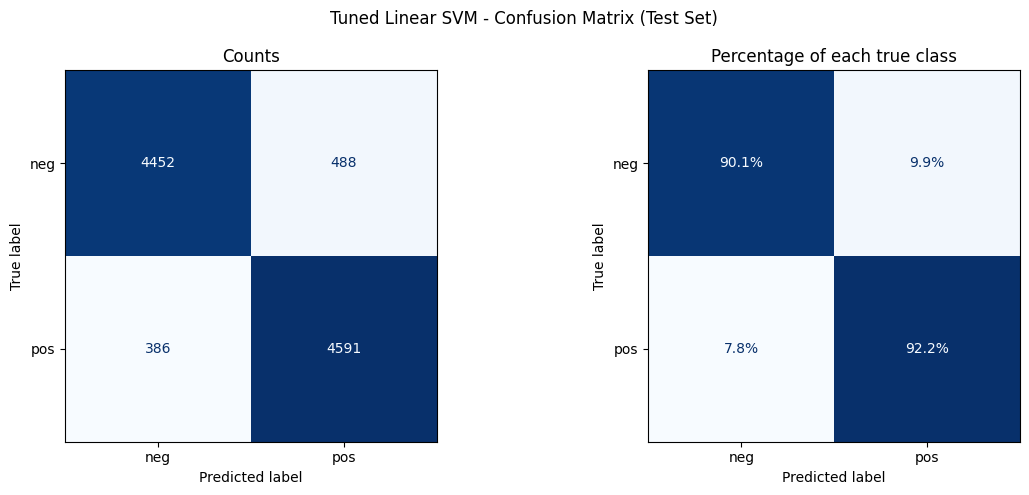

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Two confusion matrices side by side:
# left = raw counts, right = percentage of each true class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_tuned_pred,
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Counts")

# Normalized by true class (each row sums to 100%)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_tuned_pred,
    cmap="Blues",
    normalize="true",
    values_format=".1%",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Percentage of each true class")

plt.suptitle("Tuned Linear SVM - Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

In [83]:
import os
import joblib

# Folder where the model will be saved
save_dir = "/content/drive/MyDrive/Sentiment_Analysis/"

# Full path of the model file
model_path = os.path.join(save_dir, "best_sentiment_model.joblib")

# Save the full pipeline (TF-IDF + tuned Linear SVM)
joblib.dump(best_svm_model, model_path)

print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/Sentiment_Analysis/best_sentiment_model.joblib


## Results and Error Analysis

In [75]:
# Collect predictions, confidence and review length for every test review
# decision_function > 0 means "pos", < 0 means "neg"; bigger magnitude = more confident
scores = best_svm_model.decision_function(X_test)

analysis = pd.DataFrame({
    "Review": X_test.values,
    "Actual": y_test.values,
    "Predicted": svm_tuned_pred,
    "Score": scores
})
analysis["Confidence"] = analysis["Score"].abs()
analysis["Words"] = analysis["Review"].str.split().str.len()
analysis["Correct"] = analysis["Actual"] == analysis["Predicted"]

errors = analysis[~analysis["Correct"]].copy()

print("Total errors:", len(errors), "of", len(analysis))
print("\nErrors by actual class:")
print(errors["Actual"].value_counts())

Total errors: 874 of 9917

Errors by actual class:
Actual
neg    488
pos    386
Name: count, dtype: int64


In [76]:
# Compare correct vs incorrect predictions
print("Average review length (words):")
print(analysis.groupby("Correct")["Words"].mean().round(1))

print("\nAverage confidence:")
print(analysis.groupby("Correct")["Confidence"].mean().round(3))

# Error rate by review length
analysis["Length group"] = pd.qcut(
    analysis["Words"], q=4,
    labels=["Short", "Medium", "Long", "Very long"]
)
length_error = 1 - analysis.groupby("Length group", observed=True)["Correct"].mean()
print("\nError rate by review length:")
print(length_error.round(4))

Average review length (words):
Correct
False    129.1
True     130.2
Name: Words, dtype: float64

Average confidence:
Correct
False    0.311
True     0.987
Name: Confidence, dtype: float64

Error rate by review length:
Length group
Short        0.0833
Medium       0.0836
Long         0.1001
Very long    0.0856
Name: Correct, dtype: float64


In [77]:
tfidf = best_svm_model.named_steps["tfidf"]
svm = best_svm_model.named_steps["svm"]
feature_names = tfidf.get_feature_names_out()

def explain_review(text, top_n=6):
    """Return the words/phrases that pushed the prediction most strongly
    toward 'pos' and toward 'neg' (feature value x model weight)."""
    vec = tfidf.transform([text])
    idx = vec.nonzero()[1]
    contrib = vec.toarray()[0][idx] * svm.coef_[0][idx]
    order = np.argsort(contrib)
    neg_words = [(feature_names[idx[i]], round(contrib[i], 3)) for i in order[:top_n] if contrib[i] < 0]
    pos_words = [(feature_names[idx[i]], round(contrib[i], 3)) for i in order[::-1][:top_n] if contrib[i] > 0]
    return pos_words, neg_words

In [79]:
import numpy as np
pd.set_option("display.max_colwidth", None)

# Pick: the 3 most confident false positives, 3 most confident false negatives
# (most informative failures), plus 2 borderline errors
fp = errors[errors["Actual"] == "neg"].sort_values("Confidence", ascending=False).head(3)
fn = errors[errors["Actual"] == "pos"].sort_values("Confidence", ascending=False).head(3)
borderline = errors.sort_values("Confidence").head(2)

samples = pd.concat([fp, fn, borderline])

for i, (_, row) in enumerate(samples.iterrows(), start=1):
    pos_w, neg_w = explain_review(row["Review"])
    print("=" * 80)
    print(f"Example {i} | Actual: {row['Actual']} | Predicted: {row['Predicted']} "
          f"| Confidence: {row['Confidence']:.2f} | Words: {row['Words']}")
    print("-" * 80)
    print(row["Review"][:700], "..." if len(row["Review"]) > 700 else "")
    print("\nWords pushing toward POS:", pos_w)
    print("Words pushing toward NEG:", neg_w)

Example 1 | Actual: neg | Predicted: pos | Confidence: 1.71 | Words: 256
--------------------------------------------------------------------------------
mickey rourke hunt diane lane elmore leonard killshot not like mickey rourke ever really disappeared steady string appearance burst back scene memorable domino sin city man fire upon time mexico get carter but powerful dramatic performance wrestler see full blown presentation character only hinted get carter whenever get know rourke remains cool but sleazy muscle bound slim ball elmore leonard story production leonard wrote notable movie taunt western thriller yuma cool jackie brown get shorty pick up joe kidd mean get tough guy good not so good also mean get tight realistic plot character best situation weaving complication violent conclusion killshot no different tough slim ball killer rou ...

Words pushing toward POS: [('wonderful', np.float64(0.148)), ('powerful', np.float64(0.107)), ('good', np.float64(0.082)), ('enjoyable', np.

In [80]:
# Check common error causes in the misclassified reviews
negations = ["not", "no", "never", "n't", "nothing", "nobody", "neither"]
contrast = ["but", "however", "although", "though", "despite", "yet"]
mixed_cues = ["worst", "best", "great", "terrible", "boring", "excellent", "awful"]

def has_any(text, words):
    return any(w in text.split() for w in words)

summary = pd.DataFrame({
    "Contains negation": [analysis[analysis["Correct"]]["Review"].apply(lambda t: has_any(t, negations)).mean(),
                          errors["Review"].apply(lambda t: has_any(t, negations)).mean()],
    "Contains contrast word": [analysis[analysis["Correct"]]["Review"].apply(lambda t: has_any(t, contrast)).mean(),
                               errors["Review"].apply(lambda t: has_any(t, contrast)).mean()],
}, index=["Correctly classified", "Misclassified"])

display(summary.round(3))

,Contains negation,Contains contrast word
Correctly classified,0.886,0.808
Misclassified,0.895,0.865


In [81]:
coef = svm.coef_[0]
top_pos = np.argsort(coef)[-15:][::-1]
top_neg = np.argsort(coef)[:15]

print("Strongest POSITIVE features:")
print([feature_names[i] for i in top_pos])
print("\nStrongest NEGATIVE features:")
print([feature_names[i] for i in top_neg])

Strongest POSITIVE features:
['great', 'excellent', 'perfect', 'amazing', 'favorite', 'brilliant', 'wonderful', 'today', 'best', 'fun', 'loved', 'must see', 'hilarious', 'enjoyable', 'superb']

Strongest NEGATIVE features:
['worst', 'awful', 'bad', 'boring', 'poor', 'waste', 'terrible', 'nothing', 'unfortunately', 'horrible', 'disappointing', 'fails', 'disappointment', 'worse', 'dull']


In [82]:
rep = pd.DataFrame({
    "BoW": [nb_results_bow[3], lr_results_bow[3], svm_results_bow[3]],
    "TF-IDF": [nb_results_tfidf[3], lr_results_tfidf[3], svm_results_tfidf[3]],
    "TF-IDF Bigram": [nb_results_tfidf_bigram[3], lr_results_tfidf_bigram[3], svm_results_tfidf_bigram[3]],
    "Tuned": [nb_tuned_results[3], lr_tuned_results[3], svm_tuned_results[3]],
}, index=["Naive Bayes", "Logistic Regression", "Linear SVM"])

rep["Gain from tuning (vs bigram)"] = rep["Tuned"] - rep["TF-IDF Bigram"]
display(rep.round(4))

,BoW,TF-IDF,TF-IDF Bigram,Tuned,Gain from tuning (vs bigram)
Naive Bayes,0.8473,0.8558,0.8830,0.8891,0.0060
Logistic Regression,0.8883,0.8944,0.8920,0.9087,0.0167
Linear SVM,0.8675,0.8967,0.9093,0.9131,0.0037
